<div align="center">
  <h1 style="color:#2E86C1;">🛒 JV Market</h1>
</div>

## 📚 Import libraries.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys as st
import seaborn as sns
import scipy
from scipy import stats
import statsmodels.stats.proportion
from statsmodels.stats.proportion import proportions_ztest  

In [2]:
print(f"pandas:      {pd.__version__}")
print(f"numpy:       {np.__version__}")
print(f"matplotlib:  {plt.matplotlib.__version__}")
print(f"seaborn:     {sns.__version__}")
print(f"scipy:       {scipy.__version__}")
print(f"statsmodels: {statsmodels.__version__}")
print(f"Python:  {st.version_info}")

pandas:      2.2.3
numpy:       2.1.3
matplotlib:  3.10.0
seaborn:     0.13.2
scipy:       1.15.3
statsmodels: 0.14.4
Python:  sys.version_info(major=3, minor=13, micro=5, releaselevel='final', serial=0)


In [3]:
!pip freeze > requirements.txt
print("Listo! Revisa el archivo requirements.txt")

Listo! Revisa el archivo requirements.txt


## 📝 Project description.

### Prioritizing Hypotheses.

As part of its growth, **JV Market** has developed several hypothesis that will be categorized using the methods **ICE and RICE** in order to conduct a **test A/B** by implementing that hypothesis.

### Test A / B.

**JV Market conducted an A/B test to evaluate the impact of adding a subscription form to all main pages**. This test was designed to increase user engagement and conversion rates by capturing visitor information early in their journey.

**Test Setup:**
- **Group A (Control)**: Standard main pages without subscription form
- **Group B (Treatment)**: Main pages with subscription form added

This test aligns with our RICE framework analysis, where "Add a subscription form to all the main pages" ranked as the top priority hypothesis due to its high reach, impact, and confidence scores.

## 📊 Loading data.

### Hypotheses.

In [4]:
## Create a DF based on the csv file.
hypotheses = pd.read_csv('hypotheses_us.csv', sep = ";")

This **DataFrame** includes **four** columns: <br>
**• Hypotheses:** A brief description of each proposed idea. <br>
**• Reach:** Estimated number of users affected, scored from 1 to 10. <br>
**• Confidence:** Level of certainty in the result, measured from 1 to 10. <br>
**• Effort:** Level of resources required (1 to 10). A higher score indicates greater resource consumption.

### Orders.

In [5]:
## Create a DF based on the csv file.
orders = pd.read_csv('orders_us.csv')

This **DataFrame** consists of **five** columns: <br>
**• transactionId:** Order identifier. <br>
**• visitorId:** User's identifier. <br>
**• date:** Date of the order. <br>
**• revenue:** Amount of the order. <br>
**• group:** Group of the test.

### Visits.

In [6]:
## Create a DF based on the csv file.
visits = pd.read_csv('visits_us.csv')

This **DataFrame** contains **three** columns: <br>
**• date:** The specific date of the recorded visits. <br>
**• group:** The A/B test group. <br>
**• visits:** Daily visit count per group.

## 🧹 Cleaning data.

### Hypotheses.

In [7]:
## Show the first 5 rows of the DF.
hypotheses.head()

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


In [8]:
## Convert to loewrcase column names.
hypotheses.columns = hypotheses.columns.str.lower()
## Verify the changes.
hypotheses.head()

,hypothesis,reach,impact,confidence,effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


Column names in the **hypotheses DataFrame** were standardized to lowercase to simplify data manipulation.

### Orders.

In [9]:
## Show the first 5 rows of the DF.
orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


In [10]:
## Change the column names.
orders.columns = ['transaction_id', 'visitor_id', 'date', 'revenue', 'group']
## Verify the changes.
orders.head()

,transaction_id,visitor_id,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


In [11]:
## Check for duplicate values.
print(f" The total of duplicated values in the DF is: {orders.duplicated().sum()}")

 The total of duplicated values in the DF is: 0


In [12]:
## Convert to datetime the column 'date'.
orders['date'] = pd.to_datetime(orders['date'])
## Verify the changes.
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1197 non-null   int64         
 1   visitor_id      1197 non-null   int64         
 2   date            1197 non-null   datetime64[ns]
 3   revenue         1197 non-null   float64       
 4   group           1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB


### Visits.

In [13]:
## Show the first 5 rows of the DF.
visits.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [14]:
## Check for duplicate values.
print(f" The total of duplicated values in the DF is: {visits.duplicated().sum()}")

 The total of duplicated values in the DF is: 0


In [15]:
## Convert to datetime the column 'date'.
visits['date'] = pd.to_datetime(visits['date'])
## Verify the changes.
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


## 🎯🔝 Prioritizing Hypotheses.

In [16]:
## Show the DF hypotheses
hypotheses.head()

,hypothesis,reach,impact,confidence,effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


### ICE Framework.

In [17]:
## Copy the DF.
hypotheses_ice = hypotheses[['hypothesis', 'impact', 'confidence', 'effort']].copy()
## Create a new column 'ice_score'.
hypotheses_ice['ice_score'] = (
    (hypotheses_ice['impact']
     *hypotheses_ice['confidence'])
    /hypotheses_ice['effort']
)
## Apply sort_values.
hypotheses_ice = hypotheses_ice.sort_values(
    by='ice_score',
    ascending=False
).reset_index(drop=True)
## Apply format to the score.
hypotheses_ice['ice_score'] = hypotheses_ice['ice_score'].map(lambda x:"{:.2f}".format(x))
## Show the DF.
hypotheses_ice

,hypothesis,impact,confidence,effort,ice_score
0,Launch a promotion that gives users discounts ...,9,9,5,16.20
1,Add two new channels for attracting traffic. T...,10,8,6,13.33
2,Add a subscription form to all the main pages....,7,8,5,11.20
3,Show banners with current offers and sales on ...,3,8,3,8.00
4,Add product recommendation blocks to the store...,3,7,3,7.00
5,Launch your own delivery service. This will sh...,5,4,10,2.00
6,Add a customer review page. This will increase...,2,2,3,1.33
7,Change the category structure. This will incre...,3,3,8,1.12
8,Change the background color on the main page. ...,1,1,1,1.00


**"Launch a promotion that gives users discounts"** is the hypothesys that obtained the highest score. It was possible due to the high rate for the impact and confidence. Actually all the top 5 hypotheses have at least a rate of impact or confidence higher than effort rate, which means that having a high rate of effort will decrease the final score.

### RICE Framework.

In [18]:
## Copy the DF.
hypotheses_rice = hypotheses.copy()
hypotheses_rice['rice_score'] = (
    (hypotheses_rice['reach']
    *hypotheses_rice['impact']
    *hypotheses_rice['confidence'])
    / hypotheses_rice['effort']
)
## Apply sort_values.
hypotheses_rice = hypotheses_rice.sort_values(by='rice_score', ascending=False).reset_index(drop=True)
## Show the DF.
hypotheses_rice

,hypothesis,reach,impact,confidence,effort,rice_score
0,Add a subscription form to all the main pages....,10,7,8,5,112.0
1,Add product recommendation blocks to the store...,8,3,7,3,56.0
2,Add two new channels for attracting traffic. T...,3,10,8,6,40.0
3,Show banners with current offers and sales on ...,5,3,8,3,40.0
4,Launch a promotion that gives users discounts ...,1,9,9,5,16.2
5,Change the category structure. This will incre...,8,3,3,8,9.0
6,Launch your own delivery service. This will sh...,2,5,4,10,4.0
7,Add a customer review page. This will increase...,3,2,2,3,4.0
8,Change the background color on the main page. ...,3,1,1,1,3.0


This framework shows somethiing different according to the ICE framework. The first thing is that the first place is to the hypothesys: **Add a subscription form to all the main pages** and it has a clear difference taking as reference the second place. It is possible due to the reach rate, because it affects all the users. Also we can see that impact and confidence have a high rate, but by the other hand effort is not really high. <br>
Anothe important thing is that we have 2 groups of priority: <br>
**• High priority >= 40** <br>
**• Low priority < 20**

### Comparison.

In [19]:
## Create a DF to compare both frameworks.
comparison = pd.DataFrame({
    'hypothesis': hypotheses_ice['hypothesis'],
    'ice_rank': range(1, len(hypotheses_ice) + 1),
 })

## Add ranking RICE.
rice_ranks = []
for hyp in comparison['hypothesis']:
    rice_rank = hypotheses_rice[hypotheses_rice['hypothesis'] == hyp].index[0] + 1
    rice_ranks.append(rice_rank)

comparison['rice_rank'] = rice_ranks
comparison['rank_difference'] = comparison['ice_rank'] - comparison['rice_rank']

print("Comparison Rankings ICE vs RICE:")
comparison

Comparison Rankings ICE vs RICE:


,hypothesis,ice_rank,rice_rank,rank_difference
0,Launch a promotion that gives users discounts ...,1,5,-4
1,Add two new channels for attracting traffic. T...,2,3,-1
2,Add a subscription form to all the main pages....,3,1,2
3,Show banners with current offers and sales on ...,4,4,0
4,Add product recommendation blocks to the store...,5,2,3
5,Launch your own delivery service. This will sh...,6,7,-1
6,Add a customer review page. This will increase...,7,8,-1
7,Change the category structure. This will incre...,8,6,2
8,Change the background color on the main page. ...,9,9,0


Now we compared both frameworks in a DF in order to understand the differences bewtween them. **ICE rank** shows that **"Launching a promotion that gives users discounts"** is useful based on the high rate of impact and confidence, however the RICE framework places this hypothesys in 5th place due to the **low rate of Reach**. <br>
Talking about **RICE rank** shows that **"Add a subscription form to all the main pages"** is the first place due to the **high rate of Reach**. Actually this hypothesys has the same values of **impact, confidence and effort** in both frameworks, but the key to be the first place in **RICE rank** is the **Reach** as we have said. <br>
Basically, choosing between frameworks actually matters: **ICE** tends to favor high-impact but narrow initiatives, while RICE gives more credit to those that can reach a larger chunk of your users. So if you're thinking about growth, **RICE** is probably the better lens to use — it just gives us a fuller picture.

## ⚖️ Test A / B.

### Cumulative daily revenue per group.

Total cumlative revenue of the group A = $64,554.90
Total cumlative revenue of the group B = $92,840.60
The difference between the cumulative revenue of both groups is: 43.82%


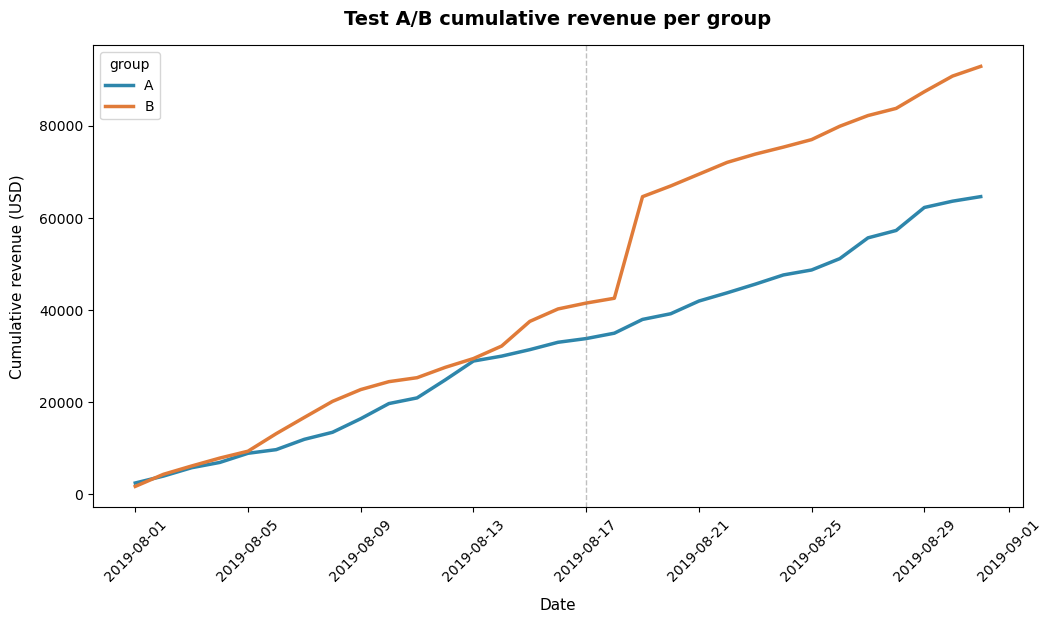

In [20]:
## Create a DF.
daily_revenue = orders.groupby(['date', 'group'])['revenue'].sum().reset_index()
## Calculate cumulative revenue per group.
daily_revenue['cumulative_revenue'] = daily_revenue.groupby('group')['revenue'].cumsum()
## Calculate max of each group.
max_a = daily_revenue[daily_revenue['group'] == 'A']['cumulative_revenue'].max()
print(f"Total cumlative revenue of the group A = ${max_a:,.2f}")
max_b = daily_revenue[daily_revenue['group'] == 'B']['cumulative_revenue'].max()
print(f"Total cumlative revenue of the group B = ${max_b:,.2f}")
## Calculate the difference in %.
difference = ((max_b/max_a)-1)*100
print(f"The difference between the cumulative revenue of both groups is: {difference:.2f}%")
## Create a graphic.
fig, ax = plt.subplots(figsize=(12, 6))
colors = {'A': '#2E86AB', 'B': '#E07B39'}
cumulative_revenue = sns.lineplot(
    data=daily_revenue,
    x='date',
    y='cumulative_revenue',
    hue='group',
    linewidth=2.5,
    markers=True,
    dashes=False,
    palette=colors,
    ax=ax
)
ax.axvline(x=pd.Timestamp('2019-08-17'), color='gray',
           linestyle='--', linewidth=1, alpha=0.5)
plt.title('Test A/B cumulative revenue per group',fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=11, labelpad=10)
plt.ylabel('Cumulative revenue (USD)', fontsize=11, labelpad=10)
plt.xticks(rotation=45)
plt.show()

According to the graphic, we can see a similar behavior during the first 16 days, but it shows n increase in Group B's revenue from **August, 17th** and resulting in a final gap of about **28,000USD** between both groups, which means **43.8% more for the group B**.

### Cumulative average order size by group.

The cumulative average order size of the group A is: $3,610.66
The cumulative average order size of the group B is: $4,470.99
The total average order size difference between gropus is: 23.83%


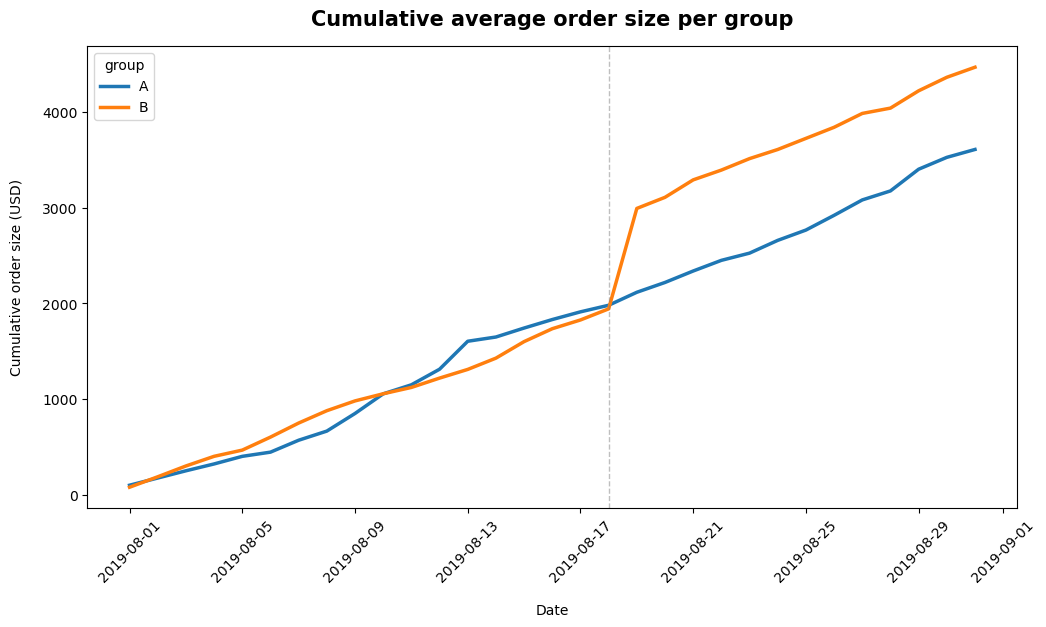

In [21]:
## Create a DF to show the cumulative average order size per group.
daily_avg = orders.groupby(['date', 'group'])['revenue'].mean().reset_index()
daily_avg.columns = ['date', 'group', 'avg_order_size']
daily_avg['cumulative_avg_order_size'] = daily_avg.groupby('group')['avg_order_size'].cumsum()
## Show the cumulative average order per group.
max_avg_a = daily_avg[daily_avg['group'] == 'A']['cumulative_avg_order_size'].max()
print(f"The cumulative average order size of the group A is: ${max_avg_a:,.2f}")
max_avg_b = daily_avg[daily_avg['group'] == 'B']['cumulative_avg_order_size'].max()
print(f"The cumulative average order size of the group B is: ${max_avg_b:,.2f}")
total_difference = ((max_avg_b / max_avg_a) -1) * 100
print(f"The total average order size difference between gropus is: {total_difference:.2f}%")

## Create a graphic to show the results.
fig, ax = plt.subplots(figsize=(12, 6))
daily_avg_comparison = sns.lineplot(
    data=daily_avg,
    x='date',
    y='cumulative_avg_order_size',
    linewidth=2.5,
    dashes=False,
    markers=True,
    hue='group',
    ax=ax
)
ax.axvline(x=pd.Timestamp('2019-08-18'), color='gray',
           linestyle='--', linewidth=1, alpha=0.5)
plt.title('Cumulative average order size per group', fontweight='bold', fontsize=15, pad=15)
plt.xlabel('Date', fontsize=10, labelpad=13)
plt.xticks(rotation=45)
plt.ylabel('Cumulative order size (USD)', fontsize=10, labelpad=13)
plt.show()

According to the graphic we can see the **group´s B increase** of the average order size, which corresponds to **23.83%**. The behavior of both groups was similar during first 16 days of the month, however, we could notice a **sharp increase from August, 19th** and it was stable to the end of the month giving as result: <br>
• Cumulative average order size of the **group A** = **3,610.66 USD**<br>
• Cumulative average order size of the **group B** = **4,470.99 USD**

The maximum relative difference between groups is: 673.33%
Date of maximum relative difference: 2019-08-19T00:00:00.000000000


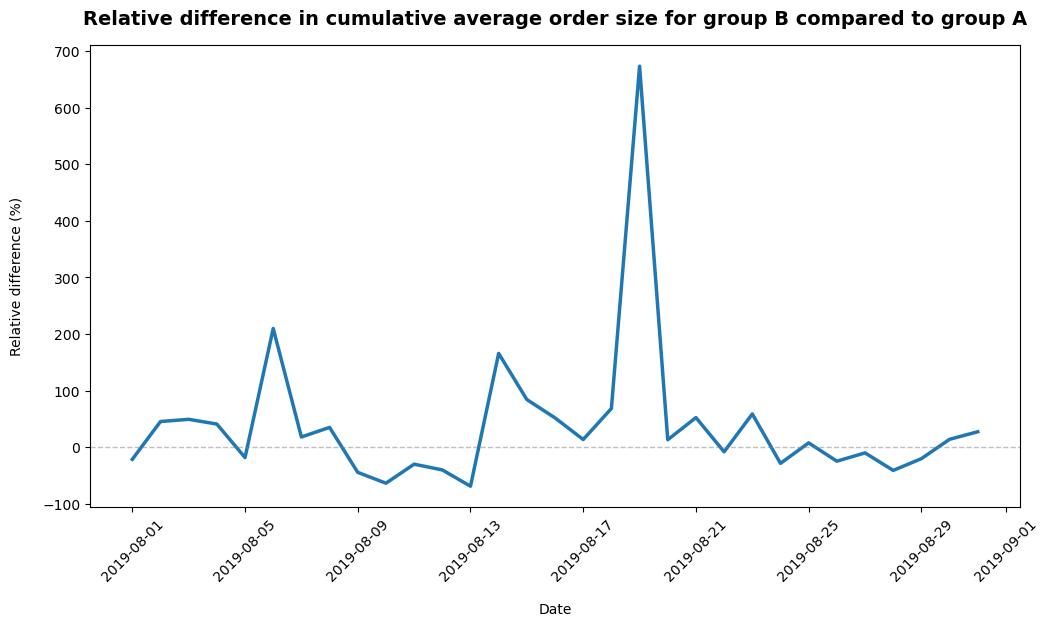

In [22]:
## Create a DF for each group to calculate average order size.
daily_avg_a = daily_avg[daily_avg['group'] == 'A'][['date', 'avg_order_size']] 
daily_avg_b = daily_avg[daily_avg['group'] == 'B'][['date', 'avg_order_size']] 
## Join both DF.
daily_avg_ = daily_avg_a.merge(daily_avg_b, on='date', suffixes=('_a', '_b'))
## Calculate the relative difference.
daily_avg_['relative_difference'] = (
    ((daily_avg_['avg_order_size_b']
    /daily_avg_['avg_order_size_a'])
    -1) * 100
)
## Show the maximum value and its date for the difference bewteen groups.
relative_difference_max = daily_avg_['relative_difference'].max()
print(f"The maximum relative difference between groups is: {relative_difference_max:.2f}%")
relative_difference_max_date = daily_avg_.loc[daily_avg_['relative_difference'] == relative_difference_max, 'date'].values[0]
print(f"Date of maximum relative difference: {relative_difference_max_date}")
## Create a graphic to show the results.
fig, ax = plt.subplots(figsize=(12,6))
relative_difference = sns.lineplot(
    data=daily_avg_,
    x='date',
    y='relative_difference',
    markers=True,
    dashes=False,
    linewidth=2.5,
    ax=ax
)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Relative difference in cumulative average order size for group B compared to group A', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=10, labelpad=13)
plt.xticks(rotation=45)
plt.ylabel('Relative difference (%)', fontsize=10, labelpad=13)
plt.show()

This graphic complements the data seen in the **cumulative average order size per group**, because it shows a **group B's** sharp increase on **August, 19th** reaching **673.33%** more than **group A**.
<br>
After that peak, the relative difference fluctuated between positive and negative values, suggesting that the sharp increase was driven by atypical orders rather than a consistent behavioral change in group B.

### Conversion rate per group.

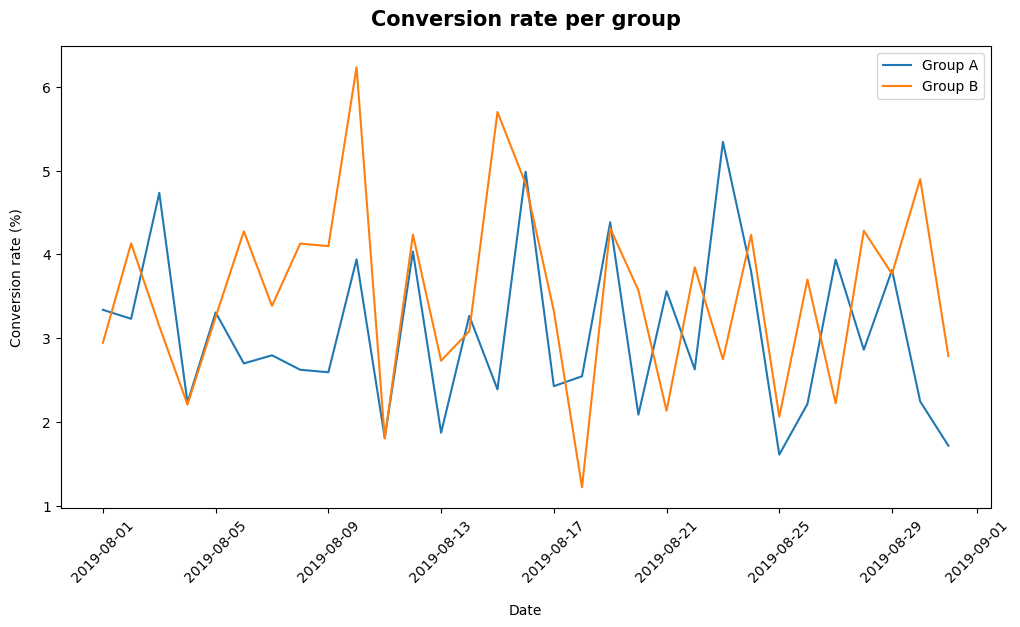

In [23]:
## Create a DF of the conversion rate group A.
conversion_rate_a = orders[orders['group'] == 'A'].groupby('date').agg({'visitor_id':'count'}).reset_index()
conversion_rate_a.columns = ['date', 'orders_a']
visits_a = visits[visits['group'] == 'A'][['date', 'visits']]
conversion_rate_a = conversion_rate_a.merge(visits_a, on='date', how='left')
conversion_rate_a.columns = ['date', 'orders_a', 'visits_a']
conversion_rate_a['conversion_rate_a'] = (conversion_rate_a['orders_a']/conversion_rate_a['visits_a'])*100
## Create a DF of the conversion rate group B.
conversion_rate_b = orders[orders['group'] == 'B'].groupby('date').agg({'visitor_id':'count'}).reset_index()
conversion_rate_b.columns = ['date', 'orders_b']
visits_b = visits[visits['group'] == 'B'][['date', 'visits']]
conversion_rate_b = conversion_rate_b.merge(visits_b, on='date', how='left')
conversion_rate_b.columns = ['date', 'orders_b', 'visits_b']
conversion_rate_b['conversion_rate_b'] = (conversion_rate_b['orders_b']/conversion_rate_b['visits_b'])*100
## Join both DF.
conversion_rate = conversion_rate_a.merge(conversion_rate_b, on='date', how='left')
## Create a graphic to show the results.
fig, ax = plt.subplots(figsize=(12,6))
group_a = sns.lineplot(
    data=conversion_rate,
    x='date',
    y='conversion_rate_a',
    label='Group A'
)
group_b = sns.lineplot(
    data=conversion_rate,
    x='date',
    y='conversion_rate_b',
    label='Group B'
)

plt.title('Conversion rate per group', fontweight='bold', fontsize=15, pad=15)
plt.xlabel('Date', fontsize=10, labelpad=13)
plt.xticks(rotation=45)
plt.ylabel('Conversion rate (%)', fontsize=10, labelpad=13)
plt.show()

Along the month we can see a similar behavior of both groups, with a slight advantage for **Group B**. The **revenue peak** seen on **August 19th was driven by atypical orders**. Notably, **Group B's highest conversion rate** was reached between **August 5th and August 9th**, approximately one week and a half before the revenue peak.

### Total orders per user.

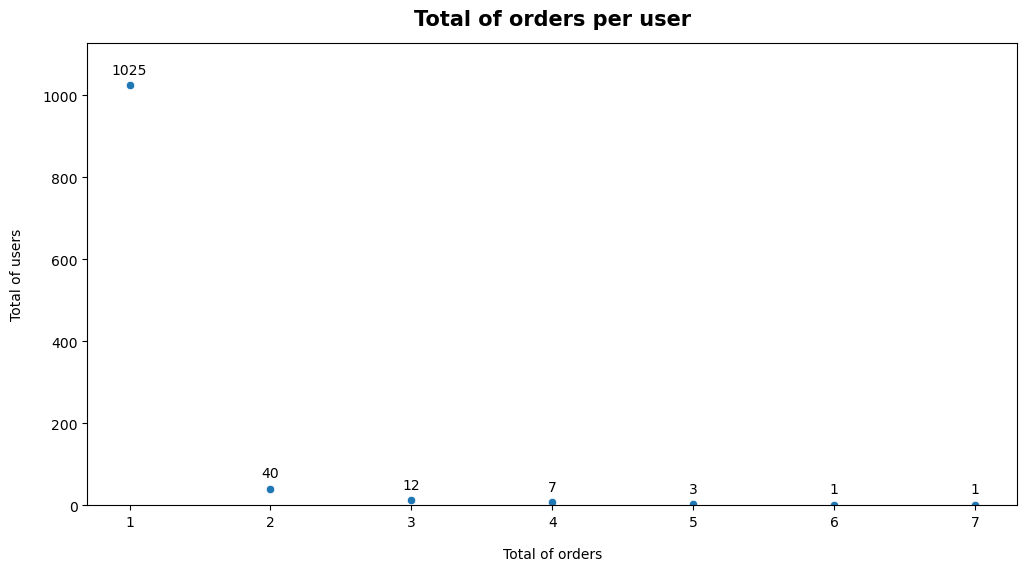

In [24]:
## Calculate total orders per visitor_id and group.
orders_per_user = orders.groupby(['visitor_id', 'group']).agg({'transaction_id':'count'}).reset_index()
## Calculate frecuency of each value obtained.
scatter_orders_per_user = orders_per_user['transaction_id'].value_counts().sort_index().reset_index()
scatter_orders_per_user.columns = ['users', 'total_orders']
## Create a graphic to show the results.
plt.subplots(figsize=(12,6))
scatter = sns.scatterplot(
    data=scatter_orders_per_user,
    x='users',
    y='total_orders'
)

for x, y in zip(scatter_orders_per_user['users'], scatter_orders_per_user['total_orders']):
    plt.text(x, y + 20, str(y), ha='center', va='bottom', fontsize=10)

plt.title('Total of orders per user', fontweight='bold', fontsize=15, pad=13)
plt.xlabel('Total of orders', fontsize=10, labelpad=13)
plt.ylabel('Total of users', fontsize=10, labelpad=13)
plt.ylim(0, scatter_orders_per_user['total_orders'].max() * 1.1)
plt.show()

In [25]:
## Calculate percentiles 95 and 99 of orders per customer.
print(f" Percentil 95 = {np.percentile(orders_per_user['transaction_id'], [95, 99])[0]} orders per customer.")
print(f" Percentil 99 = {np.percentile(orders_per_user['transaction_id'], [95, 99])[1]} orders per customer.")

 Percentil 95 = 2.0 orders per customer.
 Percentil 99 = 4.0 orders per customer.


Total orders per user shows that **40 customers bought twice**, but the most notable finding is that **1,025 users bought only once, representing 94% of the total users**. This represents a significant opportunity to improve the retention rate of JV Market by implementing **innovative strategies to increase customer engagement**.

### Price per order distribution.

In [26]:
## Create a DF including the price per order.
price_per_order = orders.groupby(['transaction_id']).agg({'revenue':'sum'}).reset_index()
## Calculate percentiles.
np.percentile(price_per_order['revenue'], [25, 50, 75, 95,99])

array([ 20.8  ,  50.2  , 130.4  , 435.54 , 900.904])

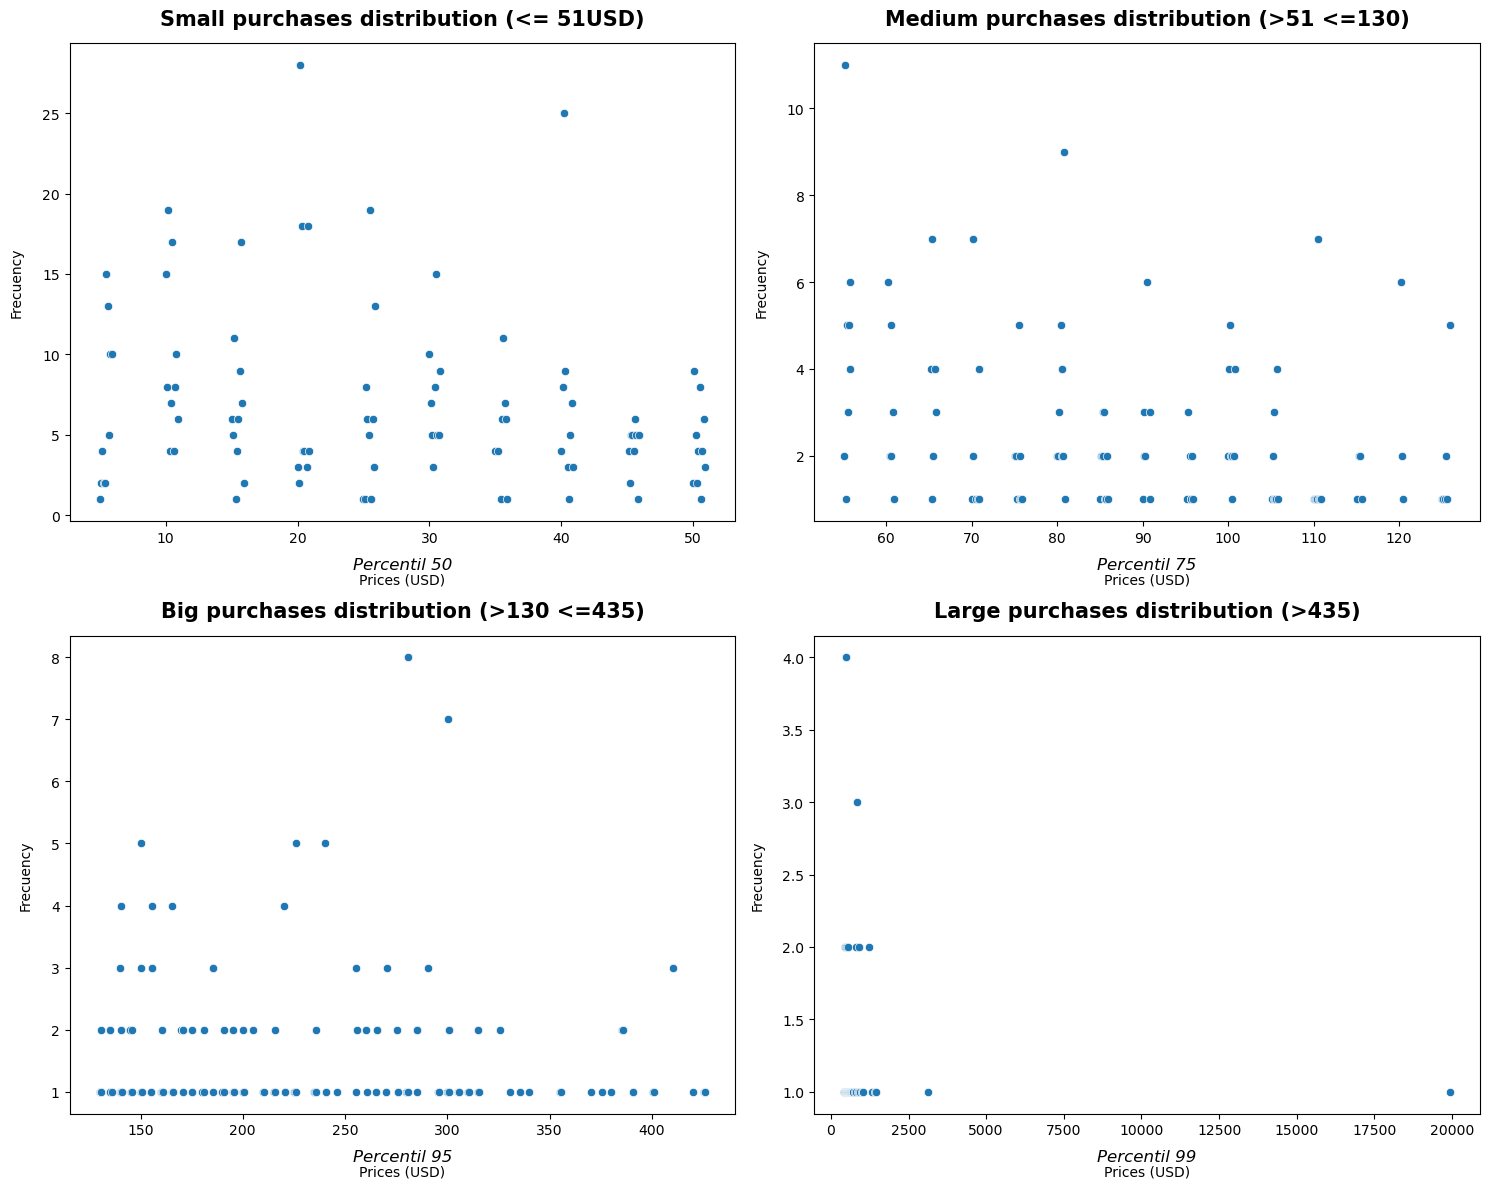

In [27]:
## Categorize according percentiles.
small_purchases = orders[orders['revenue'] <= 51]
scatter_small_purchases = small_purchases['revenue'].value_counts().sort_index().reset_index()
scatter_small_purchases.columns = ['orders', 'revenue']
medium_purchases = orders[(orders['revenue'] > 51) & (orders['revenue'] <= 130)]
scatter_medium_purchases = medium_purchases['revenue'].value_counts().sort_index().reset_index()
scatter_medium_purchases.columns = ['orders', 'revenue']
big_purchases = orders[(orders['revenue'] > 130) & (orders['revenue'] <= 435)]
scatter_big_purchases = big_purchases['revenue'].value_counts().sort_index().reset_index()
scatter_big_purchases.columns = ['orders', 'revenue']
large_purchases = orders[orders['revenue'] > 435]
scatter_large_purchases = large_purchases['revenue'].value_counts().sort_index().reset_index()
scatter_large_purchases.columns = ['orders', 'revenue']
## Create a graphic for each group.
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
## Small purchases.
scatter_small_purch = sns.scatterplot(
    data=scatter_small_purchases,
    x='orders',
    y='revenue',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Small purchases distribution (<= 51USD)', fontweight='bold', fontsize=15, pad=13)
axes[0, 0].text(0.5, -0.1, 'Percentil 50', transform=axes[0, 0].transAxes, 
                ha='center', fontsize=12, style='italic')
axes[0, 0].set_xlabel('Prices (USD)', fontsize=10, labelpad=20)
axes[0, 0].set_ylabel('Frecuency', fontsize=10, labelpad=13)
## Medium purchases.
scatter_medium_purch = sns.scatterplot(
    data=scatter_medium_purchases,
    x='orders',
    y='revenue',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Medium purchases distribution (>51 <=130)', fontweight='bold', fontsize=15, pad=13)
axes[0, 1].text(0.5, -0.1, 'Percentil 75', transform=axes[0, 1].transAxes, 
                ha='center', fontsize=12, style='italic')
axes[0, 1].set_xlabel('Prices (USD)', fontsize=10, labelpad=20)
axes[0, 1].set_ylabel('Frecuency', fontsize=10, labelpad=13)
## Big purchases.
scatter_big_purch = sns.scatterplot(
    data=scatter_big_purchases,
    x='orders',
    y='revenue',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Big purchases distribution (>130 <=435)', fontweight='bold', fontsize=15, pad=13)
axes[1, 0].text(0.5, -0.1, 'Percentil 95', transform=axes[1, 0].transAxes, 
                ha='center', fontsize=12, style='italic')
axes[1, 0].set_xlabel('Prices (USD)', fontsize=10, labelpad=20)
axes[1, 0].set_ylabel('Frecuency', fontsize=10, labelpad=13)
## Large purchases.
scatter_large_purch = sns.scatterplot(
    data=scatter_large_purchases,
    x='orders',
    y='revenue',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Large purchases distribution (>435)', fontweight='bold', fontsize=15, pad=13)
axes[1, 1].text(0.5, -0.1, 'Percentil 99', transform=axes[1, 1].transAxes, 
                ha='center', fontsize=12, style='italic')
axes[1, 1].set_xlabel('Prices (USD)', fontsize=10, labelpad=20)
axes[1, 1].set_ylabel('Frecuency', fontsize=10, labelpad=13)

plt.tight_layout()
plt.show()

Based on the percentile analysis, orders were segmented into **4 groups**: <br>
• **Small purchases**: <= 51 USD <br>
• **Medium purchases**: > 51 <= 130 USD <br>
• **Big purchases**: > 130 <= 435 USD <br>
• **Large purchases**: > 435 USD <br>
**Most of purchases fall in the small category**, showing that most customers tend to make **low-value transactions**. As the **price range increases, the frequency drops significantly**, with large purchases being rare and highly dispersed — **some reaching up to $20,000 USD**.

### Conversion rate difference between groups.

In [28]:
## Calculate total orders and visits per group.
total_orders_a = conversion_rate['orders_a'].sum()
total_visits_a = conversion_rate['visits_a'].sum()
total_orders_b = conversion_rate['orders_b'].sum()
total_visits_b = conversion_rate['visits_b'].sum()

In [29]:
count = [total_orders_b, total_orders_a]
nobs = [total_visits_b, total_visits_a]

In [30]:
stat, p_valor = proportions_ztest(count, nobs, alternative='larger')
print(f"Estadístico Z: {stat:.4f}")
print(f"P-valor: {p_valor:.6f}")

Estadístico Z: 2.2700
P-valor: 0.011604


The **Z-test** results show a **Z-statistic of 2.27 and a p-value of 0.0116**. Since the **p-value is below 0.05**, there is a **statistically significant difference** between the groups, confirming that **Group B has a higher conversion rate than Group A**.

### Order average size  difference between groups.

In [31]:
## Calculate revenue per group.
revenue_a = orders[orders['group'] == 'A'][['date', 'revenue']]
revenue_b = orders[orders['group'] == 'B'][['date', 'revenue']]

In [32]:
prueba = stats.mannwhitneyu(revenue_a['revenue'], revenue_b['revenue'])

In [33]:
print(f"Statistic value: {prueba[0]:.2f}")
print(f"P - value: {prueba.pvalue:.5f}")

Statistic value: 175872.50
P - value: 0.69152


According to **Mann-whitney U** test made, we obtained a **p-value of 0.69**, therefore we cannot conclude that there is a difference in the revenue per group along the month.

### No outliers.

In [34]:
## Create a DF by grouping per visitor_id.
abnormal_buyers = orders.groupby(['visitor_id']).agg({'transaction_id':'count'}).reset_index()
## Rename the columns.
abnormal_buyers.columns = ['visitor_id', 'total_orders']
## Filter abnormal users per total orders (> 4)
abnormal_buyers = abnormal_buyers[abnormal_buyers['total_orders'] > 4]
## Create a DF by filtering per amount and abnormal buyers.
orders_clean = orders[(orders['revenue'] <= 900) & (~orders['visitor_id'].isin(abnormal_buyers['visitor_id']))]
## Classify per group.
orders_clean_a = orders_clean[orders_clean['group'] == 'A'].groupby(['date']).agg({'visitor_id':'count'}).reset_index()
orders_clean_a.columns = ['date', 'orders_clean_a']
orders_clean_b = orders_clean[orders_clean['group'] == 'B'].groupby(['date']).agg({'visitor_id':'count'}).reset_index()
orders_clean_b.columns = ['date', 'orders_clean_b']
## Copy the DF conversion_rate.
conversion_rate_filtered = conversion_rate.copy()
## Join conversion_rate_filtered with orders_clean for each group.
conversion_rate_filtered = conversion_rate_filtered.merge(orders_clean_a, on='date', how='left')
conversion_rate_filtered = conversion_rate_filtered.merge(orders_clean_b, on='date', how='left')
## Calculate visits clean for each group.
conversion_rate_filtered['visits_clean_a'] = conversion_rate_filtered['visits_a'] - (conversion_rate_filtered['orders_a'] - conversion_rate_filtered['orders_clean_a'])
conversion_rate_filtered['visits_clean_b'] = conversion_rate_filtered['visits_b'] - (conversion_rate_filtered['orders_b'] - conversion_rate_filtered['orders_clean_b'])
conversion_rate_filtered['conversion_rate_a_filtered'] = (
    (conversion_rate_filtered['orders_clean_a'] 
     /conversion_rate_filtered['visits_clean_a']))*100
conversion_rate_filtered['conversion_rate_b_filtered'] = (
    (conversion_rate_filtered['orders_clean_b'] 
     /conversion_rate_filtered['visits_clean_b']))*100

In order to determine if **extreme values affect the metrics**, we have cleaned them using the **99th percentile** as a reference for the **number of purchases per customer** and for the **transaction amount**, so that transactions from users **with more than 4 purchases** have been eliminated, as well as **transactions** greater than **900 USD**.

### (No outliers) Conversion rate difference between groups.

In [35]:
## Calculate total orders and visits per group.
total_orders_a_filtered = conversion_rate_filtered['orders_a'].sum()
total_visits_a_filtered = conversion_rate_filtered['visits_clean_a'].sum()
total_orders_b_filtered = conversion_rate_filtered['orders_b'].sum()
total_visits_b_filtered = conversion_rate_filtered['visits_clean_b'].sum()

In [36]:
count_filtered = [total_orders_b_filtered, total_orders_a_filtered]
nobs_filtered = [total_visits_b_filtered, total_visits_a_filtered]
stat, p_valor = proportions_ztest(count_filtered, nobs_filtered, alternative='larger')
print(f"Estadístico Z: {stat:.4f}")
print(f"P-valor: {p_valor:.6f}")

Estadístico Z: 2.2669
P-valor: 0.011698


Once we have cleaned abnormal users in the last step, we can notice that the **p-value** is very **similar (0.011)**, therefore it confirms that **extreme values do not affect** the metrics and **Group B has a higher conversion rate than Group A** even after removing outliers.

### (No outliers) Order average size  difference between groups.

In [37]:
revenue_a_clean = orders_clean[orders_clean['group'] == 'A'][['date', 'revenue']]
revenue_b_clean = orders_clean[orders_clean['group'] == 'B'][['date', 'revenue']]
proof = stats.mannwhitneyu(revenue_a_clean['revenue'], revenue_b_clean['revenue'])
print(f"P-value: {proof.pvalue:.6f}")


P-value: 0.933184


After removing outliers, the **p-value increased to 0.933**, further confirming that **there is no statistically significant difference in the order size between groups**. This suggests that **the outliers were introducing noise in the previous analysis**.

## 🏁 Final Conclusions.

Based on the different **tests carried out and metrics calculated**, we can conclude that **the A/B test** focused on increasing the conversion rate **was successful**. This result is supported by the **p-value (0.0116)** obtained with the Z-test. It is important to mention that the test showed very **similar results before and after removing outliers**. However, most customers just **bought once**, so it is important to work on **encouraging customers to buy recurrently**. Regarding revenue, we noticed a **Group B increase**, however, this change was driven by **atypical purchases** on August 19th. <br>
Given these results, it is **recommended** to **implement Group B's strategy as the new standard**, while developing **loyalty programs or incentives to increase** the purchase frequency among existing customers.